# 📐 Propriedades de Árvores

Neste notebook, exploraremos as **propriedades fundamentais** das árvores e o **teorema central** que as caracteriza.

## Objetivos

- Compreender o teorema fundamental sobre árvores
- Explorar as 5 definições equivalentes de árvore
- Demonstrar propriedades com exemplos práticos
- Verificar computacionalmente as propriedades

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

## 🔑 Teorema Fundamental

> **Teorema**: Um grafo $G$ é uma árvore **se, e somente se**, existir **um e apenas um caminho** entre cada par de vértices.

### Interpretação

- **"Se"** (⇒): Se G é árvore → existe caminho único
- **"Somente se"** (⇐): Se existe caminho único → G é árvore

### Por quê é importante?

Este teorema estabelece a **característica essencial** de uma árvore: a **unicidade de caminhos**.

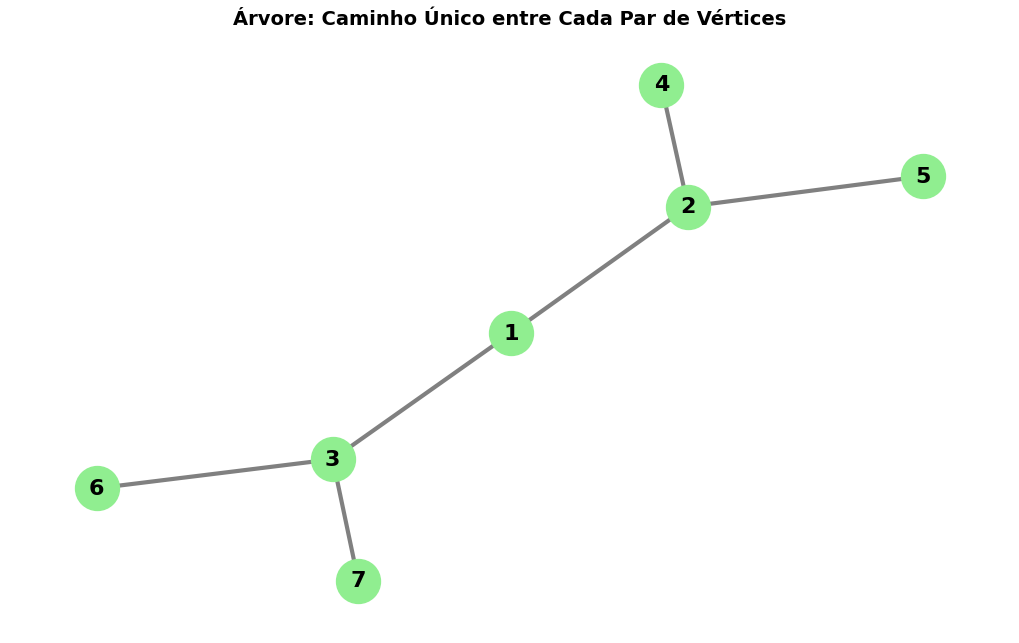


🔍 Verificando unicidade de caminhos:
  1 → 2: [1, 2]  (Total de caminhos: 1)
  1 → 3: [1, 3]  (Total de caminhos: 1)
  1 → 4: [1, 2, 4]  (Total de caminhos: 1)
  1 → 5: [1, 2, 5]  (Total de caminhos: 1)
  1 → 6: [1, 3, 6]  (Total de caminhos: 1)
  1 → 7: [1, 3, 7]  (Total de caminhos: 1)
  2 → 3: [2, 1, 3]  (Total de caminhos: 1)
  2 → 4: [2, 4]  (Total de caminhos: 1)
  2 → 5: [2, 5]  (Total de caminhos: 1)
  2 → 6: [2, 1, 3, 6]  (Total de caminhos: 1)
  2 → 7: [2, 1, 3, 7]  (Total de caminhos: 1)
  3 → 4: [3, 1, 2, 4]  (Total de caminhos: 1)
  3 → 5: [3, 1, 2, 5]  (Total de caminhos: 1)
  3 → 6: [3, 6]  (Total de caminhos: 1)
  3 → 7: [3, 7]  (Total de caminhos: 1)
  4 → 5: [4, 2, 5]  (Total de caminhos: 1)
  4 → 6: [4, 2, 1, 3, 6]  (Total de caminhos: 1)
  4 → 7: [4, 2, 1, 3, 7]  (Total de caminhos: 1)
  5 → 6: [5, 2, 1, 3, 6]  (Total de caminhos: 1)
  5 → 7: [5, 2, 1, 3, 7]  (Total de caminhos: 1)
  6 → 7: [6, 3, 7]  (Total de caminhos: 1)

✓ Em uma árvore, TODOS os pares têm EXAT

In [2]:
# Demonstração: Caminho único em árvore
T = nx.Graph()
T.add_edges_from([
    (1, 2), (1, 3),
    (2, 4), (2, 5),
    (3, 6), (3, 7)
])

# Visualizar
pos = nx.spring_layout(T, seed=42)
plt.figure(figsize=(10, 6))
nx.draw(T, pos, with_labels=True, node_color='lightgreen',
        node_size=1000, font_size=16, font_weight='bold', edge_color='gray', width=3)
plt.title('Árvore: Caminho Único entre Cada Par de Vértices', fontsize=14, fontweight='bold')
plt.show()

# Verificar caminhos entre todos os pares
print("\n🔍 Verificando unicidade de caminhos:")
print("="*60)

vertices = list(T.nodes())
for i in range(len(vertices)):
    for j in range(i+1, len(vertices)):
        v, w = vertices[i], vertices[j]
        # Em árvores, só existe UM caminho
        paths = list(nx.all_simple_paths(T, v, w))
        path = nx.shortest_path(T, v, w)
        print(f"  {v} → {w}: {path}  (Total de caminhos: {len(paths)})")

print("\n✓ Em uma árvore, TODOS os pares têm EXATAMENTE 1 caminho!")

## 🎯 As 5 Definições Equivalentes de Árvore

Para um grafo $G(V, A)$ com $n$ vértices, as seguintes afirmações são **equivalentes**:

### 1️⃣ $G$ é uma árvore
Definição original: grafo conexo sem ciclos

### 2️⃣ $G$ é conexo e possui $n-1$ arestas
Caracterização por número de arestas

### 3️⃣ $G$ possui $n-1$ arestas e não possui circuitos
Caracterização por ausência de ciclos com contagem

### 4️⃣ Existe exatamente um caminho entre cada par de vértices
Teorema fundamental (unicidade)

### 5️⃣ $G$ não contém circuitos, e para todo $v, w \in V$, a adição da aresta $(v,w)$ produz **exatamente um circuito**
Caracterização por propriedade de adição de arestas

---

> **Importante**: Qualquer uma dessas definições pode ser usada para **definir** uma árvore!

## 📊 Verificação das 5 Definições

In [3]:
def verificar_5_definicoes(G):
    """
    Verifica as 5 definições equivalentes de árvore
    """
    n = G.number_of_nodes()
    m = G.number_of_edges()
    
    print(f"\n{'='*70}")
    print(f"VERIFICANDO AS 5 DEFINIÇÕES EQUIVALENTES")
    print(f"{'='*70}")
    print(f"Grafo com {n} vértices e {m} arestas\n")
    
    # Definição 1: É árvore (conexo + sem ciclos)
    conexo = nx.is_connected(G)
    sem_ciclos = nx.is_forest(G)  # floresta = sem ciclos
    def1 = conexo and sem_ciclos
    print(f"1️⃣  G é conexo E sem ciclos?")
    print(f"    Conexo: {conexo}")
    print(f"    Sem ciclos: {sem_ciclos}")
    print(f"    → Resultado: {def1} {'✓' if def1 else '✗'}\n")
    
    # Definição 2: Conexo + n-1 arestas
    tem_n_menos_1 = (m == n - 1)
    def2 = conexo and tem_n_menos_1
    print(f"2️⃣  G é conexo E tem n-1 arestas?")
    print(f"    Conexo: {conexo}")
    print(f"    m = n-1? {m} = {n-1}? {tem_n_menos_1}")
    print(f"    → Resultado: {def2} {'✓' if def2 else '✗'}\n")
    
    # Definição 3: n-1 arestas + sem ciclos
    def3 = tem_n_menos_1 and sem_ciclos
    print(f"3️⃣  G tem n-1 arestas E não tem ciclos?")
    print(f"    m = n-1? {tem_n_menos_1}")
    print(f"    Sem ciclos: {sem_ciclos}")
    print(f"    → Resultado: {def3} {'✓' if def3 else '✗'}\n")
    
    # Definição 4: Caminho único entre cada par
    caminho_unico = True
    if conexo:
        vertices = list(G.nodes())
        for i in range(min(3, len(vertices))):  # testar alguns pares
            for j in range(i+1, min(4, len(vertices))):
                paths = list(nx.all_simple_paths(G, vertices[i], vertices[j]))
                if len(paths) != 1:
                    caminho_unico = False
                    break
    else:
        caminho_unico = False
    
    def4 = caminho_unico
    print(f"4️⃣  Existe exatamente 1 caminho entre cada par?")
    print(f"    → Resultado: {def4} {'✓' if def4 else '✗'}\n")
    
    # Definição 5: Adicionar aresta cria exatamente 1 ciclo
    def5 = False
    if sem_ciclos:
        # Testar com um par de vértices não conectados
        vertices = list(G.nodes())
        if len(vertices) >= 2:
            v, w = vertices[0], vertices[-1]
            if not G.has_edge(v, w):
                G_test = G.copy()
                G_test.add_edge(v, w)
                # Contar ciclos após adição
                try:
                    cycle_basis = nx.cycle_basis(G_test)
                    def5 = len(cycle_basis) == 1
                except:
                    def5 = False
    
    print(f"5️⃣  Sem ciclos, e adicionar aresta cria exatamente 1 ciclo?")
    print(f"    → Resultado: {def5} {'✓' if def5 else '✗'}\n")
    
    # Conclusão
    todas = def1 and def2 and def3 and def4 and def5
    print(f"{'='*70}")
    print(f"TODAS as 5 definições são equivalentes? {todas} {'🌳' if todas else '❌'}")
    print(f"{'='*70}\n")
    
    return todas

# Testar com uma árvore válida
T = nx.balanced_tree(2, 2)  # árvore binária balanceada
verificar_5_definicoes(T)


VERIFICANDO AS 5 DEFINIÇÕES EQUIVALENTES
Grafo com 7 vértices e 6 arestas

1️⃣  G é conexo E sem ciclos?
    Conexo: True
    Sem ciclos: True
    → Resultado: True ✓

2️⃣  G é conexo E tem n-1 arestas?
    Conexo: True
    m = n-1? 6 = 6? True
    → Resultado: True ✓

3️⃣  G tem n-1 arestas E não tem ciclos?
    m = n-1? True
    Sem ciclos: True
    → Resultado: True ✓

4️⃣  Existe exatamente 1 caminho entre cada par?
    → Resultado: True ✓

5️⃣  Sem ciclos, e adicionar aresta cria exatamente 1 ciclo?
    → Resultado: True ✓

TODAS as 5 definições são equivalentes? True 🌳



True

## 🔬 Demonstração Visual da Definição 5

**Definição 5**: $G$ não contém ciclos, e adicionar qualquer aresta cria **exatamente um ciclo**.

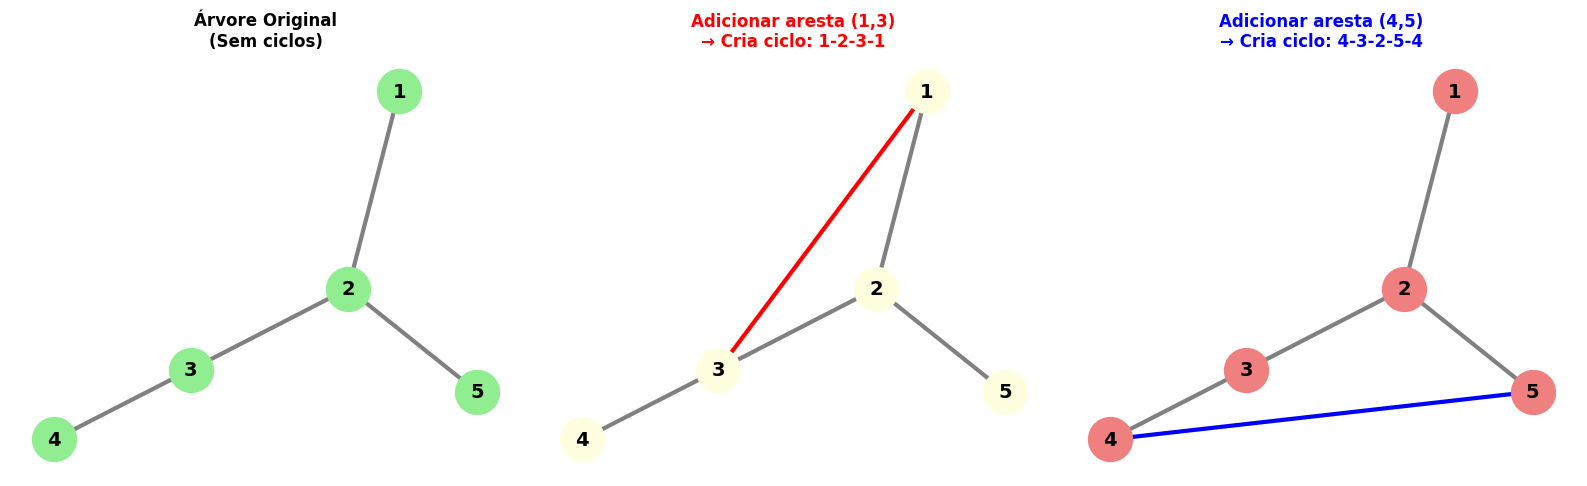


📌 Propriedade:
  Em uma árvore, adicionar QUALQUER aresta entre vértices não adjacentes
  cria EXATAMENTE UM ciclo (usando o caminho único que já existia).


In [4]:
# Criar uma árvore simples
T = nx.Graph()
T.add_edges_from([(1,2), (2,3), (3,4), (2,5)])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Árvore original (sem ciclos)
pos = nx.spring_layout(T, seed=42)
nx.draw(T, pos, ax=axes[0], with_labels=True, node_color='lightgreen',
        node_size=1000, font_size=14, font_weight='bold', edge_color='gray', width=3)
axes[0].set_title('Árvore Original\n(Sem ciclos)', fontweight='bold', fontsize=12)

# 2. Adicionar aresta 1-3 (cria ciclo)
T2 = T.copy()
T2.add_edge(1, 3)
edge_colors = ['red' if e == (1,3) or e == (3,1) else 'gray' for e in T2.edges()]
nx.draw(T2, pos, ax=axes[1], with_labels=True, node_color='lightyellow',
        node_size=1000, font_size=14, font_weight='bold', edge_color=edge_colors, width=3)
axes[1].set_title('Adicionar aresta (1,3)\n→ Cria ciclo: 1-2-3-1', 
                  fontweight='bold', fontsize=12, color='red')

# 3. Adicionar aresta 4-5 (cria outro ciclo)
T3 = T.copy()
T3.add_edge(4, 5)
edge_colors = ['blue' if e == (4,5) or e == (5,4) else 'gray' for e in T3.edges()]
nx.draw(T3, pos, ax=axes[2], with_labels=True, node_color='lightcoral',
        node_size=1000, font_size=14, font_weight='bold', edge_color=edge_colors, width=3)
axes[2].set_title('Adicionar aresta (4,5)\n→ Cria ciclo: 4-3-2-5-4',
                  fontweight='bold', fontsize=12, color='blue')

plt.tight_layout()
plt.show()

print("\n📌 Propriedade:")
print("  Em uma árvore, adicionar QUALQUER aresta entre vértices não adjacentes")
print("  cria EXATAMENTE UM ciclo (usando o caminho único que já existia).")

## 📐 Propriedade: $n$ vértices → $n-1$ arestas

> **Teorema**: Uma árvore com $n$ vértices tem **exatamente** $n-1$ arestas.

### Por quê?

- Começamos com **1 vértice** (0 arestas)
- Cada vértice adicionado requer **exatamente 1 aresta** para conectar à árvore
- Após adicionar $n-1$ vértices: $n-1$ arestas

### Consequência

- **Menos que $n-1$**: desconexo
- **Mais que $n-1$**: tem ciclos
- **Exatamente $n-1$**: pode ser árvore (se conexo e sem ciclos)

In [5]:
# Demonstrar a relação n-1 para diferentes árvores
tamanhos = [3, 5, 7, 10, 15, 20]
resultados = []

for n in tamanhos:
    # Criar árvore aleatória com n vértices
    T = nx.random_tree(n, seed=42)
    m = T.number_of_edges()
    resultados.append((n, m, m == n-1))

print("\n📊 Relação n-1 em Árvores de Diferentes Tamanhos")
print("="*60)
print(f"{'Vértices (n)':<15} {'Arestas (m)':<15} {'m = n-1?':<15} {'Verificação'}")
print("="*60)

for n, m, valido in resultados:
    print(f"{n:<15} {m:<15} {n-1:<15} {'✓' if valido else '✗'}")

print("\n✓ TODAS as árvores satisfazem m = n - 1")

AttributeError: module 'networkx' has no attribute 'random_tree'

## 🧮 Propriedade: Soma dos Graus

### Lema Fundamental

Para qualquer grafo $G(V, A)$:

$$\sum_{v \in V} \text{grau}(v) = 2 |A|$$

### Para Árvores

Como $|A| = n - 1$:

$$\sum_{v \in V} \text{grau}(v) = 2(n-1) = 2n - 2$$

In [ ]:
# Criar árvore e verificar soma dos graus
T = nx.random_tree(10, seed=100)
n = T.number_of_nodes()
m = T.number_of_edges()

# Calcular graus
graus = dict(T.degree())
soma_graus = sum(graus.values())

print("\n🔢 Soma dos Graus em Árvore")
print("="*50)
print(f"Vértices (n): {n}")
print(f"Arestas (m): {m}")
print(f"\nGraus dos vértices: {list(graus.values())}")
print(f"\nSoma dos graus: {soma_graus}")
print(f"2 × m = 2 × {m} = {2*m}")
print(f"2(n-1) = 2 × {n-1} = {2*(n-1)}")
print(f"\n✓ Verificação: {soma_graus} = {2*m} = {2*(n-1)}")

## 🍃 Propriedade: Vértices Pendentes

> **Observação**: Toda árvore não-trivial (com 2 ou mais vértices) tem **pelo menos 2 vértices pendentes** (grau 1).

### Demonstração (ideia)

- Começar em qualquer vértice
- Seguir caminho sem repetir vértices
- Como não há ciclos, eventualmente chegamos a um **beco sem saída** (vértice pendente)
- O mesmo vale na direção oposta
- Logo: pelo menos 2 pendentes

In [ ]:
# Verificar vértices pendentes em diferentes árvores
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, n in enumerate([4, 6, 8, 10, 12, 15]):
    T = nx.random_tree(n, seed=i)
    
    # Identificar pendentes
    pendentes = [v for v in T.nodes() if T.degree(v) == 1]
    internos = [v for v in T.nodes() if T.degree(v) > 1]
    
    # Colorir: verde=pendente, azul=interno
    cores = ['lightgreen' if v in pendentes else 'lightblue' for v in T.nodes()]
    
    pos = nx.spring_layout(T, seed=42)
    nx.draw(T, pos, ax=axes[i], with_labels=True, node_color=cores,
            node_size=600, font_size=10, font_weight='bold', edge_color='gray', width=2)
    axes[i].set_title(f'n={n}, pendentes={len(pendentes)}\n(verde=pendente)',
                     fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n🍃 Contagem de Vértices Pendentes")
print("="*60)
print(f"{'n (vértices)':<15} {'Pendentes':<15} {'≥ 2?'}")
print("="*60)

for i, n in enumerate([4, 6, 8, 10, 12, 15]):
    T = nx.random_tree(n, seed=i)
    pendentes = sum(1 for v in T.nodes() if T.degree(v) == 1)
    print(f"{n:<15} {pendentes:<15} {'✓' if pendentes >= 2 else '✗'}")

print("\n✓ Toda árvore não-trivial tem pelo menos 2 vértices pendentes")

## 🎯 Aplicação: Construindo Árvores Incrementalmente

In [ ]:
# Construir árvore passo a passo
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

T = nx.Graph()
arestas_adicionar = [(1,2), (1,3), (2,4), (2,5), (3,6)]

for i, (ax, aresta) in enumerate(zip(axes, [(None, None)] + arestas_adicionar)):
    if aresta[0] is not None:
        T.add_edge(*aresta)
    
    if T.number_of_nodes() > 0:
        n = T.number_of_nodes()
        m = T.number_of_edges()
        
        pos = nx.spring_layout(T, seed=42)
        nx.draw(T, pos, ax=ax, with_labels=True, node_color='lightgreen',
                node_size=800, font_size=14, font_weight='bold', edge_color='gray', width=3)
        
        ax.set_title(f'Passo {i}: n={n}, m={m}\nm = n-1? {m == n-1} {"|✓|" if m == n-1 else "| "}',
                    fontsize=11, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Início\n(grafo vazio)', ha='center', va='center',
               fontsize=14, fontweight='bold', transform=ax.transAxes)
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
    
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\n✓ A cada vértice adicionado, adicionamos EXATAMENTE 1 aresta")
print("✓ Isso mantém a propriedade m = n - 1")

## 🎯 Resumo das Propriedades

### Teorema Fundamental

> $G$ é árvore ⇔ existe **um único caminho** entre cada par de vértices

### As 5 Definições Equivalentes

Para $G(V, A)$ com $n$ vértices, as seguintes são **EQUIVALENTES**:

| # | Definição |
|---|----------|
| 1 | $G$ é árvore (conexo + sem ciclos) |
| 2 | $G$ é conexo e tem $n-1$ arestas |
| 3 | $G$ tem $n-1$ arestas e sem ciclos |
| 4 | Existe exatamente 1 caminho entre cada par |
| 5 | Sem ciclos, e adicionar aresta cria exatamente 1 ciclo |

### Propriedades Derivadas

- ✅ $|A| = n - 1$ (número de arestas)
- ✅ $\sum \text{grau}(v) = 2n - 2$ (soma dos graus)
- ✅ Pelo menos 2 vértices pendentes (grau 1)
- ✅ Remover qualquer aresta desconecta o grafo
- ✅ Adicionar qualquer aresta cria exatamente 1 ciclo

### Próximo Notebook

No próximo notebook, estudaremos **árvores enraizadas** e **árvores binárias completas**!

## 📝 Exercícios

1. Prove que removendo qualquer aresta de uma árvore, o grafo se torna desconexo.
2. Mostre que uma árvore com $n$ vértices tem no máximo $n-2$ vértices internos.
3. Crie uma função que verifique se adicionar uma aresta a um grafo cria exatamente um ciclo.
4. Demonstre que em uma árvore com $n \geq 2$ vértices, $\sum_{v: \text{grau}(v)=1} 1 \geq 2$.
5. Construa uma árvore com exatamente 5 vértices pendentes.